**<h1>Session 7: Grover's Algorithm: Quantum Search and Amplitude Amplification</h1>**

In [1]:
#Imports
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from itertools import product
from qiskit.circuit.library import GroverOperator, MCMT, ZGate, XGate
from qiskit.circuit.library import MCMTGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile
import math
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

In [2]:
#A function returning all possible bit strings of length num_bits
def bit_list(num_bits):
    bit_strings = [bin(bit)[2:].zfill(num_bits) for bit in range(2**num_bits)]
    bit_lists = []
    for string in bit_strings:
        bit_lists.append([int(bit) for bit in string])
    return  bit_strings, bit_lists

In [3]:
#A function that outputs the truth table of a given oracle
def check_truth_table(len_x, oracle):

    print('Oracle:')
    qx = QuantumRegister(len_x, 'x')
    qy = QuantumRegister(1, 'y')
    qc = QuantumCircuit(qy,qx)
    oracle(qc, qx, qy)
    display(qc.draw(reverse_bits=True))

    print('Bit ordering is x_n,...,x_0,y \n')

    basis_states, _ = bit_list(len_x+1)
    for state in basis_states:
        qx = QuantumRegister(len_x, 'x')
        qy = QuantumRegister(1, 'y')
        qc = QuantumCircuit(qy,qx)

        for i in range(len_x+1):
            if state[len_x-i] == '1':
                qc.x(i)

        sv_in = Statevector(qc)

        oracle(qc, qx, qy)

        sv = Statevector(qc)
        print(f"In: \t {sv_in.draw('latex').data[4:4+len_x+1]} \t Out: \t {sv.draw('latex').data[4:4+len_x+1]} \t f+y: \t {sv.draw('latex').data[4+len_x]} \n")


#1/ Practice with oracles

**Example 1**

Here is an example of a function $f$ which always outputs 0. The table summarizing for all possible bit combinations is here:

| $x$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | $y$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; |  $f(x)$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | $f(x)\oplus y$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;  |
| :-------------------------------- | :-------------------------------- | :-------------------------------- |:-------------------------------- |
 |0 | 0 | 0 | 0 |
 |0| 1 | 0 | 1 |
 |1 | 0| 0 | 0 |
 |1| 1| 0 | 1 |

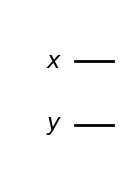

In [4]:
#Corresponding quantum oracle
## build two quantum registers
qx= QuantumRegister(1, 'x')
qy= QuantumRegister(1, 'y')
qc= QuantumCircuit(qx, qy)
## build oracle
def oracle(qc, qx, qy):
    pass
qc.draw(output='mpl')

In [5]:
#Let's check with a truthtable

check_truth_table(len_x=1, oracle=oracle)

Oracle:


x: 
   
y:

Bit ordering is x_n,...,x_0,y 

In: 	 00 	 Out: 	 00 	 f+y: 	 0 

In: 	 01 	 Out: 	 01 	 f+y: 	 1 

In: 	 10 	 Out: 	 10 	 f+y: 	 0 

In: 	 11 	 Out: 	 11 	 f+y: 	 1 



**Example 2**

Here is an example which implements the following balanced $f$.

| $x$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | $y$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; |  $f(x)$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | $f(x)\oplus y$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;  |
| :-------------------------------- | :-------------------------------- | :-------------------------------- |:-------------------------------- |
 |0 | 0 | 0 | 0 |
 |0| 1 | 0 | 1 |
 |1 | 0| 1 | 1 |
 |1| 1| 1 | 0 |


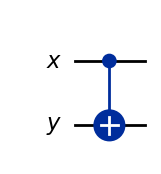

In [6]:
#Corresponding quantum oracle

## build two quantum registers
qx=QuantumRegister(1,'x')
qy= QuantumRegister(1,'y')
qc= QuantumCircuit(qx, qy)

## build oracle
qc.cx(qx[0], qy[0])
qc.draw(output='mpl')

In [7]:
#Let's check with a truthtable
def oracle(qc, qx, qy):
    qc.cx(qx[0], qy[0])
check_truth_table(len_x=1, oracle=oracle)

Oracle:


x: ──■──
   ┌─┴─┐
y: ┤ X ├
   └───┘

Bit ordering is x_n,...,x_0,y 

In: 	 00 	 Out: 	 00 	 f+y: 	 0 

In: 	 01 	 Out: 	 01 	 f+y: 	 1 

In: 	 10 	 Out: 	 11 	 f+y: 	 1 

In: 	 11 	 Out: 	 10 	 f+y: 	 0 



## Exercises

**A)** Create a circuit which implements $U_f$ for the following $f$:

| $x$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | $y$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; |  $f(x)$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | $f(x)\oplus y$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;   |
| :-------------------------------- | :-------------------------------- | :-------------------------------- |:-------------------------------- |
 |0 | 0 | 1 | 1 |
 |0| 1 | 1 | 0 |
 |1 | 0| 1 | 1 |
 |1| 1| 1 | 0 |

In [34]:
def oracle(qc, qx, qy):
    qc.x(qy[0])
check_truth_table(len_x=1, oracle=oracle)

Oracle:


x: ─────
   ┌───┐
y: ┤ X ├
   └───┘

Bit ordering is x_n,...,x_0,y 

In: 	 00 	 Out: 	 01 	 f+y: 	 1 

In: 	 01 	 Out: 	 00 	 f+y: 	 0 

In: 	 10 	 Out: 	 11 	 f+y: 	 1 

In: 	 11 	 Out: 	 10 	 f+y: 	 0 



**B)** Create a circuit which implements $U_f$ for the following $f$:

| $x$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | $y$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; |  $f(x)$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | $f(x)\oplus y$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;  |
| :-------------------------------- | :-------------------------------- | :-------------------------------- |:-------------------------------- |
 |0 | 0 | 1 | 1 |
 |0| 1 | 1 | 0 |
 |1 | 0| 0 | 0 |
 |1| 1| 0 | 1 |

In [35]:
def oracle(qc, qx, qy):
    qc.x(qx[0])
    qc.cx(qx[0], qy[0])
    qc.x(qx[0])
check_truth_table(len_x=1, oracle=oracle)

Oracle:


┌───┐     ┌───┐
x: ┤ X ├──■──┤ X ├
   └───┘┌─┴─┐└───┘
y: ─────┤ X ├─────
        └───┘

Bit ordering is x_n,...,x_0,y 

In: 	 00 	 Out: 	 01 	 f+y: 	 1 

In: 	 01 	 Out: 	 00 	 f+y: 	 0 

In: 	 10 	 Out: 	 10 	 f+y: 	 0 

In: 	 11 	 Out: 	 11 	 f+y: 	 1 



Can you build an oracle which implements $U_f$ for the following $f$?

| $x_1$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; |$x_0$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | $y$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; |  $f(x_0,x_1)$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;  &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;| $f(x_0,x_1)\oplus y$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; |
| :-------------------------------- | :-------------------------------- | :-------------------------------- |:-------------------------------- | :-------------------------------- |
 |0 |0 | 0 | 0 | 0 |
 |0 |0| 1 | 0 | 1 |
 |0 |1 | 0| 1 | 1 |
 |0 |1| 1| 1 | 0 |
 |1 |0 | 0 | 1 | 1 |
 |1 |0| 1 | 1 | 0 |
 |1 |1 | 0| 0 | 0 |
 |1 |1| 1| 0 | 1 |


In [36]:
def oracle(qc, qx, qy):
    # Apply CNOT from x0 to y: y = y ⊕ x0
    qc.cx(qx[0], qy[0])

    # Apply CNOT from x1 to y: y = (y ⊕ x0) ⊕ x1
    qc.cx(qx[1], qy[0])

# Testing parameters
num_qubits = 2
check_truth_table(len_x=num_qubits, oracle=oracle)

Oracle:


x_1: ───────■──
            │  
x_0: ──■────┼──
     ┌─┴─┐┌─┴─┐
  y: ┤ X ├┤ X ├
     └───┘└───┘

Bit ordering is x_n,...,x_0,y 

In: 	 000 	 Out: 	 000 	 f+y: 	 0 

In: 	 001 	 Out: 	 001 	 f+y: 	 1 

In: 	 010 	 Out: 	 011 	 f+y: 	 1 

In: 	 011 	 Out: 	 010 	 f+y: 	 0 

In: 	 100 	 Out: 	 101 	 f+y: 	 1 

In: 	 101 	 Out: 	 100 	 f+y: 	 0 

In: 	 110 	 Out: 	 110 	 f+y: 	 0 

In: 	 111 	 Out: 	 111 	 f+y: 	 1 



#2/ Phase Flip Oracles Designs

Consider a two-qubit system with target state '01'.

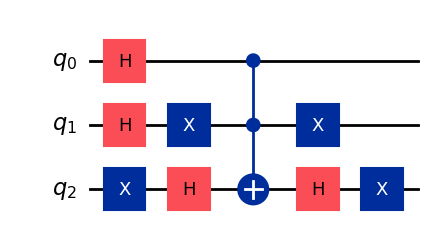

In [8]:
target_state = '01'

# Flip target bit-string to match Qiskit bit-ordering
rev_target = target_state[::-1]

num_qubits = len(target_state)

# Create quantum circuit with main register + ancilla qubit
qc = QuantumCircuit(num_qubits + 1)

# Step 1: Prepare the ancilla in |-> state
qc.x(num_qubits)
qc.h(num_qubits)

# Step 2: Apply Hadamard to all main qubits to be in complete superposition
for i in range(num_qubits):
    qc.h(i)

# Apply X gates based on target_state (flip where target bit = 0)
for i in range(num_qubits):
    if rev_target[i] == '0':
        qc.x(i)

# Apply multi-controlled NOT targeting the ancilla
# This flips the ancilla when all main qubits are |1>
qc.ccx(0, 1, 2)

# Flip X gates back (uncompute)
for i in range(num_qubits):
    if rev_target[i] == '0':
        qc.x(i)
# Return ancilla to computational basis
qc.h(num_qubits)
qc.x(num_qubits)

qc.draw(output='mpl')

We can print out the state vector at the end of the circuit to see what is going on.

In [9]:
display(Statevector(qc).draw('latex'))

<IPython.core.display.Latex object>

Consider a four-qubit system with target state '0010'.

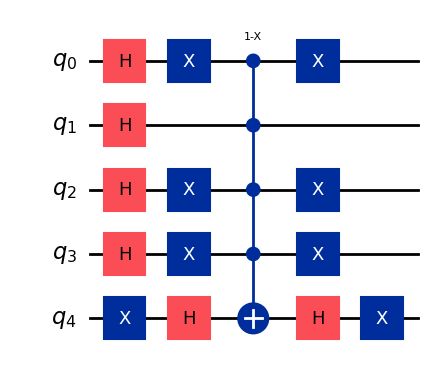

In [10]:
from qiskit.circuit.library import XGate

target_state = '0010'

# Flip target bit-string to match Qiskit bit-ordering
rev_target = target_state[::-1]

num_qubits = len(target_state)

# Create quantum circuit with main register + ancilla qubit
qc = QuantumCircuit(num_qubits + 1)

# Step 1: Prepare the ancilla in |-> state
qc.x(num_qubits)
qc.h(num_qubits)

# Step 2: Apply Hadamard to all main qubits to be in complete superposition
for i in range(num_qubits):
    qc.h(i)

# Apply X gates based on target_state (flip where target bit = 0)
qc.x(0)
qc.x(2)
qc.x(3)

# Apply multi-controlled NOT targeting the ancilla
# This flips the ancilla when all main qubits are |1>
control_qubits = [0, 1, 2, 3]
qc.compose(MCMTGate(XGate(), len(control_qubits), 1), control_qubits + [num_qubits], inplace=True) # Controls: qubits 0,1,2,3; Target: ancilla (qubit 4)

# Flip X gates back (uncompute)
qc.x(0)
qc.x(2)
qc.x(3)

# Return ancilla to |-> basis
qc.h(num_qubits)
qc.x(num_qubits)

qc.draw(output='mpl')

We can print out the state vector at the end of the circuit to see what is going on.

In [11]:
display(Statevector(qc).draw('latex'))

<IPython.core.display.Latex object>

Can you make an oracle which flips the phase of two states? See if you can make one which flips the phases of the states encoding bit strings '001' and '101'.

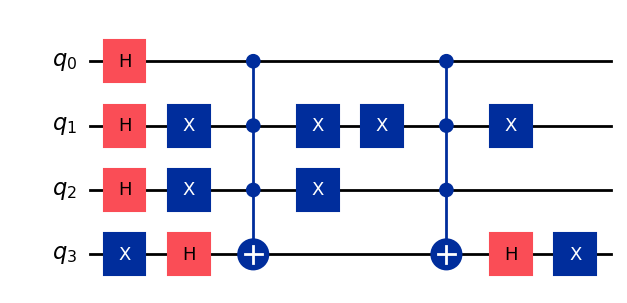

In [37]:
# Target states to flip the phase of
target_states = ['001', '101']

num_qubits = len(target_states[0])

# Create quantum circuit with main register + ancilla qubit
qc = QuantumCircuit(num_qubits + 1)

# Step 1: Prepare the ancilla in |-> state
qc.x(num_qubits)
qc.h(num_qubits)

# Step 2: Apply Hadamard to all main qubits to be in complete superposition
for i in range(num_qubits):
    qc.h(i)

# For each target state, we'll create a controlled operation
for target_state in target_states:
    # Flip target bit-string to match Qiskit bit-ordering
    rev_target = target_state[::-1]

    # Apply X gates based on target_state (flip where target bit = 0)
    for i in range(num_qubits):
        if rev_target[i] == '0':
            qc.x(i)

    # Apply multi-controlled NOT targeting the ancilla
    qc.mcx([0, 1, 2], 3)

    # Flip X gates back (uncompute)
    for i in range(num_qubits):
        if rev_target[i] == '0':
            qc.x(i)

# Return ancilla to computational basis
qc.h(num_qubits)
qc.x(num_qubits)

qc.draw(output='mpl')

In [38]:
display(Statevector(qc).draw('latex'))

<IPython.core.display.Latex object>

##Oracle General format

Let's construct the phase flip oracle for an arbitrary target state, and then turn that into a function we can use later.

In [12]:
def mark_target_state(qc, target_state, ancilla_qubit):

    num_main_qubits = len(target_state)

    # Apply X gates to qubits where target_state bit is '0'
    for qubit_idx, bit in enumerate(target_state[::-1]):
        if bit == '0':
            qc.x(qubit_idx)

    # Apply multi-controlled NOT targeting the ancilla
    # This flips the ancilla when all main qubits are |1> in the transformed basis
    control_qubits = list(range(num_main_qubits))
    qc.compose(MCMTGate(XGate(), len(control_qubits), 1),
               control_qubits + [ancilla_qubit], inplace=True)

    # Uncompute: flip back the X gates
    for qubit_idx, bit in enumerate(target_state[::-1]):
        if bit == '0':
            qc.x(qubit_idx)

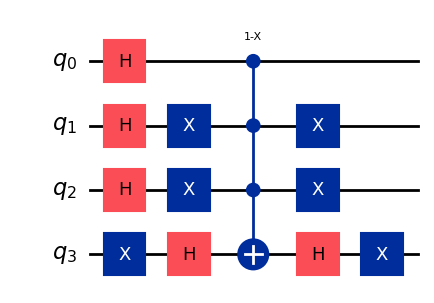

In [13]:
# Define target state
target_state = '001'
num_qubits = len(target_state)

# Create quantum circuit with main register + ancilla qubit
qc = QuantumCircuit(num_qubits + 1)

# Step 1: Prepare the ancilla in |-> state
qc.x(num_qubits)
qc.h(num_qubits)

# Step 2: Apply Hadamard to all main qubits to be in complete superposition
for i in range(num_qubits):
    qc.h(i)

# Use the generalized function to mark the target state '1010'
mark_target_state(qc, target_state, num_qubits)

# Return ancilla to |-> basis
qc.h(num_qubits)
qc.x(num_qubits)

qc.draw(output='mpl')

In [14]:
display(Statevector(qc).draw('latex'))

<IPython.core.display.Latex object>

Can you do the same task but with more target states?

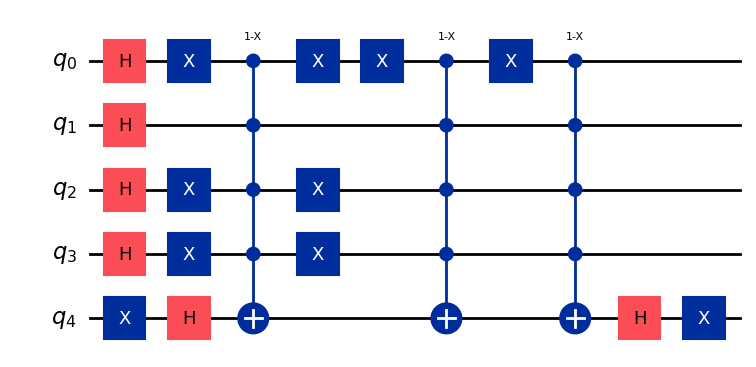

In [39]:
def mark_target_states(qc, target_states, ancilla_qubit):

    num_main_qubits = len(target_states[0])

    # Check all target states have same length
    for state in target_states:
        if len(state) != num_main_qubits:
            raise ValueError(f"All target states must have same length. Got {len(state)} for {state}")

    # For each target state, create the marking operation
    for target_state in target_states:
        # Apply X gates to qubits where target_state bit is '0'
        for qubit_idx, bit in enumerate(target_state[::-1]):  # Reverse for Qiskit ordering
            if bit == '0':
                qc.x(qubit_idx)

        # Apply multi-controlled NOT targeting the ancilla
        # This flips the ancilla when all main qubits are |1> in the transformed basis
        control_qubits = list(range(num_main_qubits))
        qc.compose(MCMTGate(XGate(), len(control_qubits), 1),
                   control_qubits + [ancilla_qubit], inplace=True)

        # Uncompute: flip back the X gates
        for qubit_idx, bit in enumerate(target_state[::-1]):
            if bit == '0':
                qc.x(qubit_idx)

# Define multiple target states
target_states = ['0010', '1110', '1111']  # Mark 3 states
num_qubits = len(target_states[0])  # All should have same length

# Create quantum circuit with main register + ancilla qubit
qc = QuantumCircuit(num_qubits + 1)

# Step 1: Prepare the ancilla in |-> state
qc.x(num_qubits)
qc.h(num_qubits)

# Step 2: Apply Hadamard to all main qubits to be in complete superposition
for i in range(num_qubits):
    qc.h(i)

# Use the generalized function to mark multiple target states
mark_target_states(qc, target_states, num_qubits)

# Return ancilla to computational basis
qc.h(num_qubits)
qc.x(num_qubits)

qc.draw(output='mpl')

In [40]:
display(Statevector(qc).draw('latex'))

<IPython.core.display.Latex object>

#3/ Amplitude Amplification

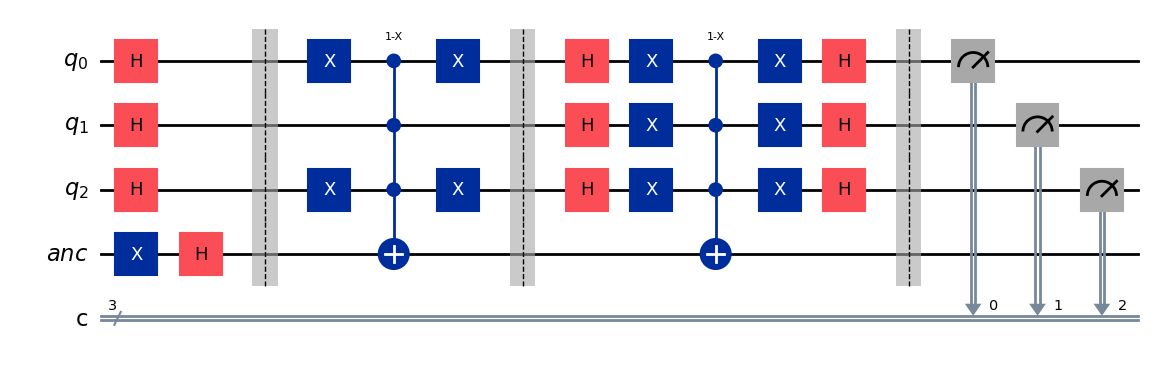

In [16]:
# Setup
qr = QuantumRegister(3, 'q')
anc = QuantumRegister(1, 'anc')
cr = ClassicalRegister(3, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Initialize
for i in range(3):
    qc.h(qr[i])
qc.x(anc[0])
qc.h(anc[0])
qc.barrier()

# Oracle for |010⟩
qc.x(qr[0])
qc.x(qr[2])
# Use MCMTGate for 3-controlled X gate
mct_oracle_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_oracle_gate, qr[:] + anc[:], inplace=True)
qc.x(qr[0])  # Unflip
qc.x(qr[2])  # Unflip
qc.barrier()

# Diffusion
for i in range(3):
    qc.h(qr[i])
    qc.x(qr[i])
# Use MCMTGate for 3-controlled X gate
mct_diffusion_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_diffusion_gate, qr[:] + anc[:], inplace=True)
for i in range(3):
    qc.x(qr[i])
    qc.h(qr[i])
qc.barrier()

# 4. Measure
qc.measure(qr, cr)

qc.draw(output='mpl')

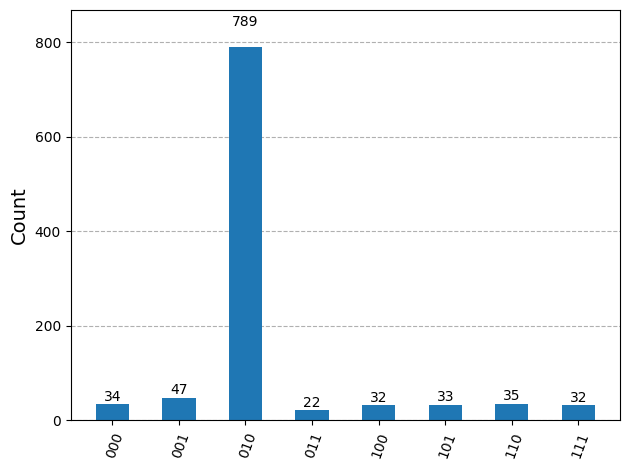

In [17]:
#Ideal Simulator
backend = AerSimulator()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

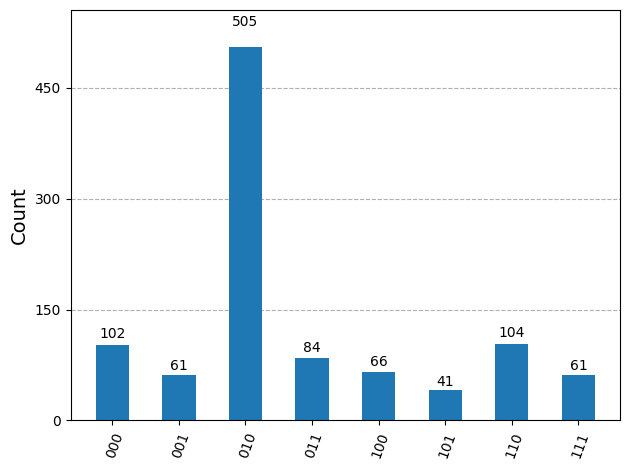

In [18]:
#Noisy simulator
backend = FakeSherbrooke()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

What happens if we repeat the amplitude amplification process again?

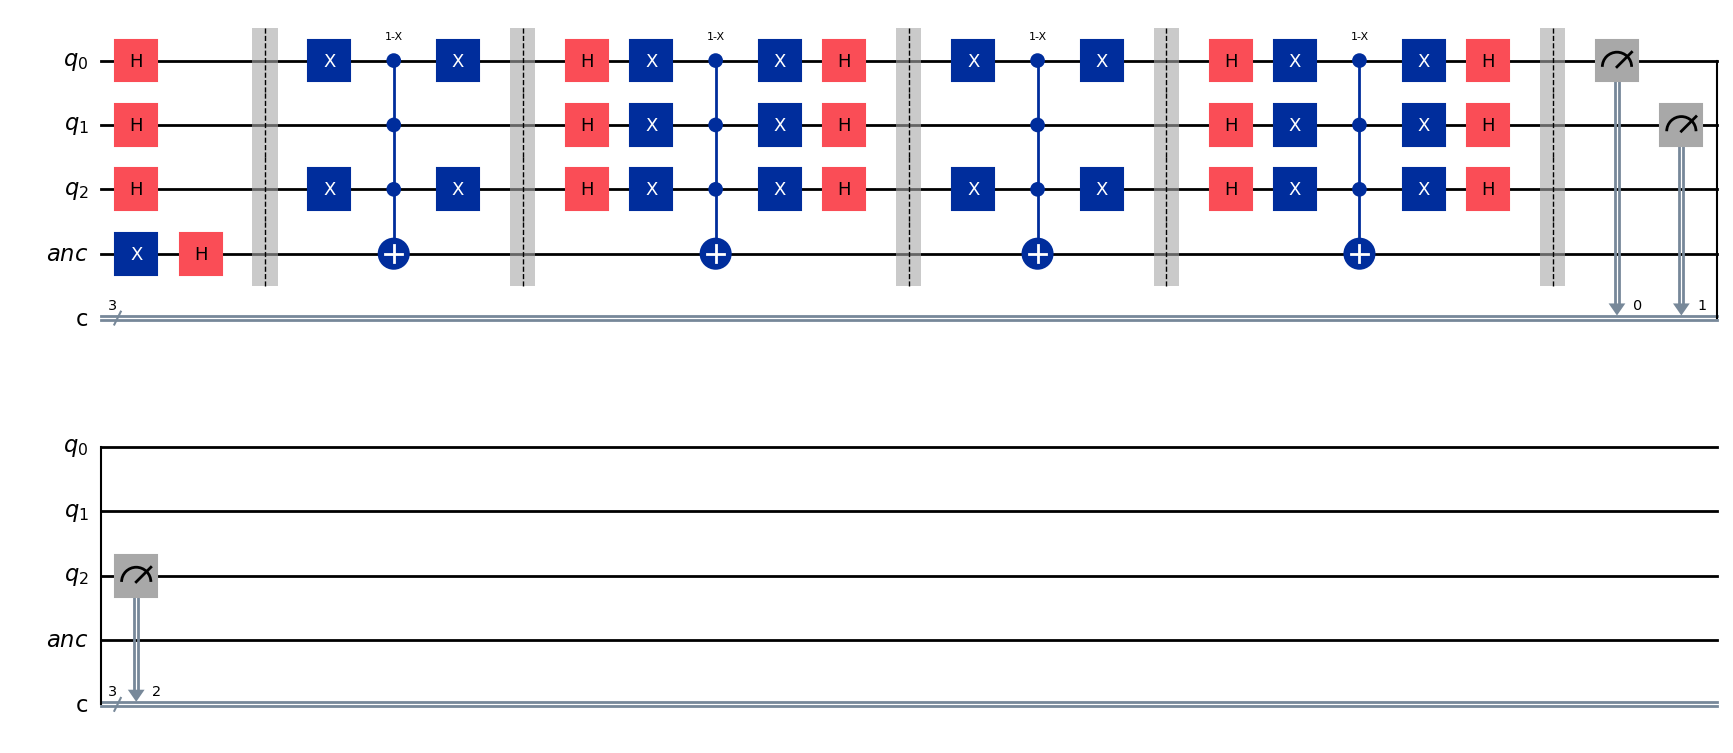

In [19]:
# Setup
qr = QuantumRegister(3, 'q')
anc = QuantumRegister(1, 'anc')
cr = ClassicalRegister(3, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Initialize
for i in range(3):
    qc.h(qr[i])
qc.x(anc[0])
qc.h(anc[0])
qc.barrier()

# Oracle for |010⟩
qc.x(qr[0])
qc.x(qr[2])
# Use MCMTGate for 3-controlled X gate
mct_oracle_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_oracle_gate, qr[:] + anc[:], inplace=True)
qc.x(qr[0])  # Unflip
qc.x(qr[2])  # Unflip
qc.barrier()

# Diffusion
for i in range(3):
    qc.h(qr[i])
    qc.x(qr[i])
# Use MCMTGate for 3-controlled X gate
mct_diffusion_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_diffusion_gate, qr[:] + anc[:], inplace=True)
for i in range(3):
    qc.x(qr[i])
    qc.h(qr[i])
qc.barrier()

# Oracle for |010⟩
qc.x(qr[0])
qc.x(qr[2])
# Use MCMTGate for 3-controlled X gate
mct_oracle_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_oracle_gate, qr[:] + anc[:], inplace=True)
qc.x(qr[0])  # Unflip
qc.x(qr[2])  # Unflip
qc.barrier()

# Diffusion
for i in range(3):
    qc.h(qr[i])
    qc.x(qr[i])
# Use MCMTGate for 3-controlled X gate
mct_diffusion_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_diffusion_gate, qr[:] + anc[:], inplace=True)
for i in range(3):
    qc.x(qr[i])
    qc.h(qr[i])
qc.barrier()

# 4. Measure
qc.measure(qr, cr)

qc.draw(output='mpl')

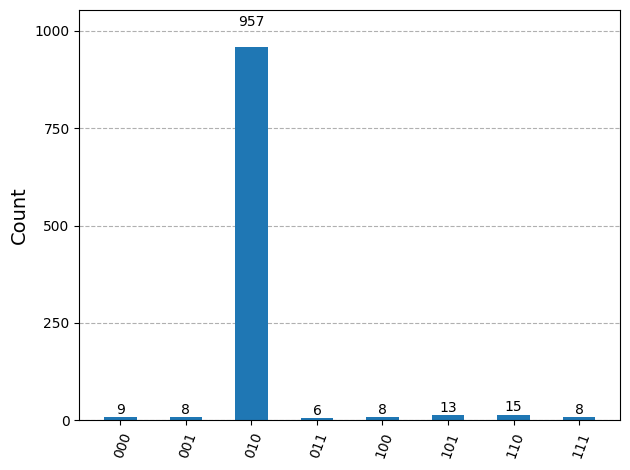

In [20]:
backend = AerSimulator()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

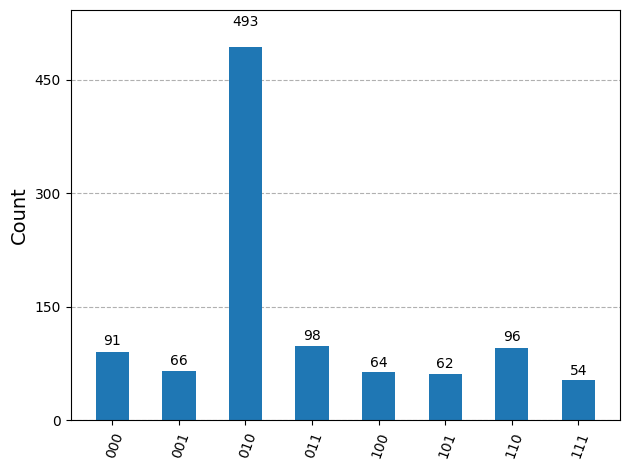

In [21]:
backend = FakeSherbrooke()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

What happens if you repeat the amplitude amplification three times?

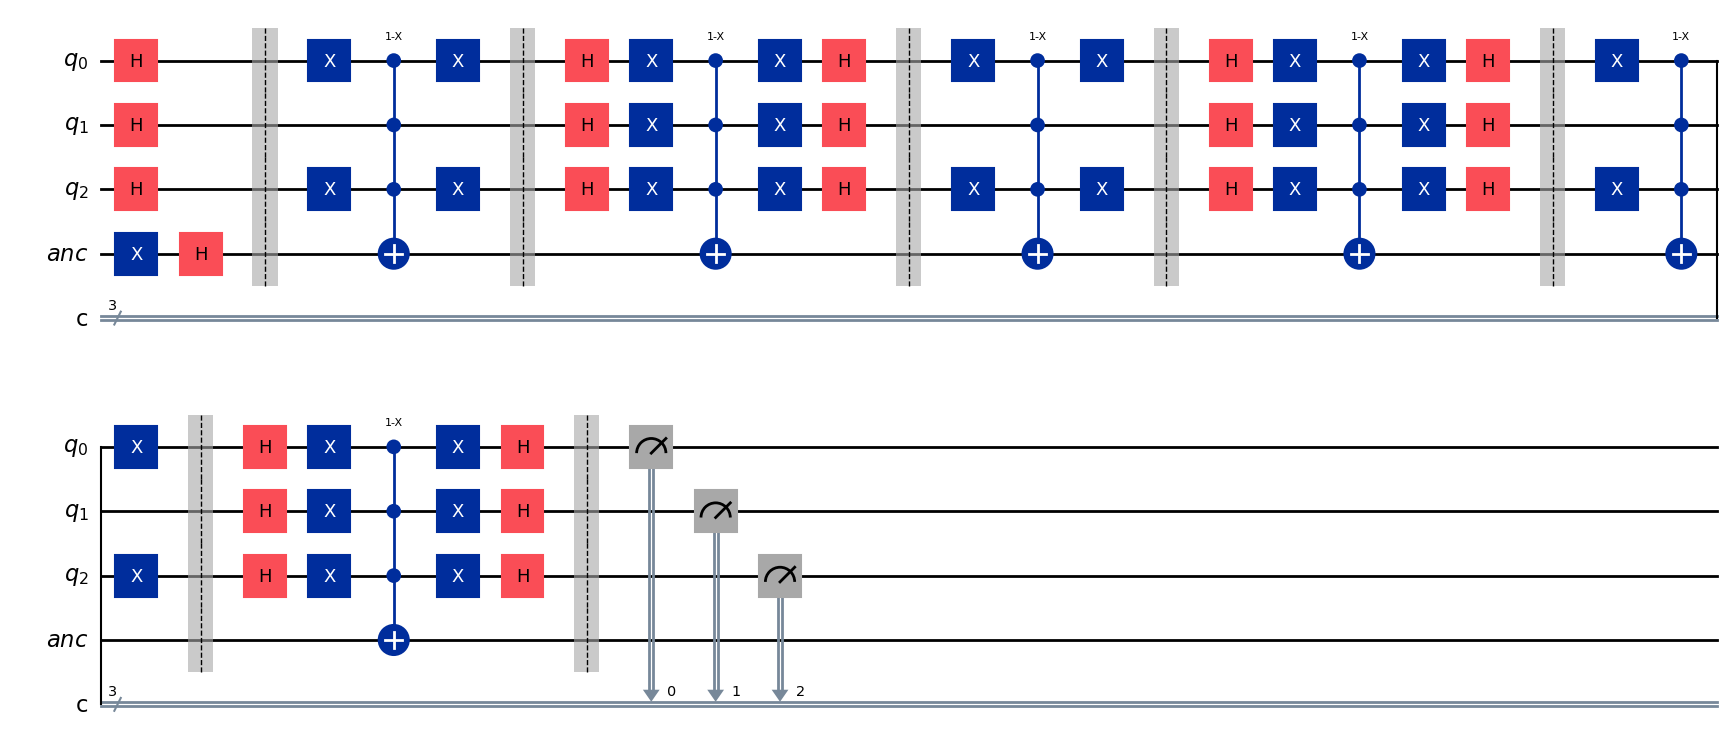

In [22]:
# Setup
qr = QuantumRegister(3, 'q')
anc = QuantumRegister(1, 'anc')
cr = ClassicalRegister(3, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Initialize
for i in range(3):
    qc.h(qr[i])
qc.x(anc[0])
qc.h(anc[0])
qc.barrier()

# Oracle for |010⟩
qc.x(qr[0])
qc.x(qr[2])
# Use MCMTGate for 3-controlled X gate
mct_oracle_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_oracle_gate, qr[:] + anc[:], inplace=True)
qc.x(qr[0])  # Unflip
qc.x(qr[2])  # Unflip
qc.barrier()

# Diffusion
for i in range(3):
    qc.h(qr[i])
    qc.x(qr[i])
# Use MCMTGate for 3-controlled X gate
mct_diffusion_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_diffusion_gate, qr[:] + anc[:], inplace=True)
for i in range(3):
    qc.x(qr[i])
    qc.h(qr[i])
qc.barrier()

# Oracle for |010⟩
qc.x(qr[0])
qc.x(qr[2])
# Use MCMTGate for 3-controlled X gate
mct_oracle_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_oracle_gate, qr[:] + anc[:], inplace=True)
qc.x(qr[0])  # Unflip
qc.x(qr[2])  # Unflip
qc.barrier()

# Diffusion
for i in range(3):
    qc.h(qr[i])
    qc.x(qr[i])
# Use MCMTGate for 3-controlled X gate
mct_diffusion_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_diffusion_gate, qr[:] + anc[:], inplace=True)
for i in range(3):
    qc.x(qr[i])
    qc.h(qr[i])
qc.barrier()

# Oracle for |010⟩
qc.x(qr[0])
qc.x(qr[2])
# Use MCMTGate for 3-controlled X gate
mct_oracle_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_oracle_gate, qr[:] + anc[:], inplace=True)
qc.x(qr[0])  # Unflip
qc.x(qr[2])  # Unflip
qc.barrier()

# Diffusion
for i in range(3):
    qc.h(qr[i])
    qc.x(qr[i])
# Use MCMTGate for 3-controlled X gate
mct_diffusion_gate = MCMTGate(XGate(), 3, 1)
qc.compose(mct_diffusion_gate, qr[:] + anc[:], inplace=True)
for i in range(3):
    qc.x(qr[i])
    qc.h(qr[i])
qc.barrier()

# 4. Measure
qc.measure(qr, cr)

qc.draw(output='mpl')

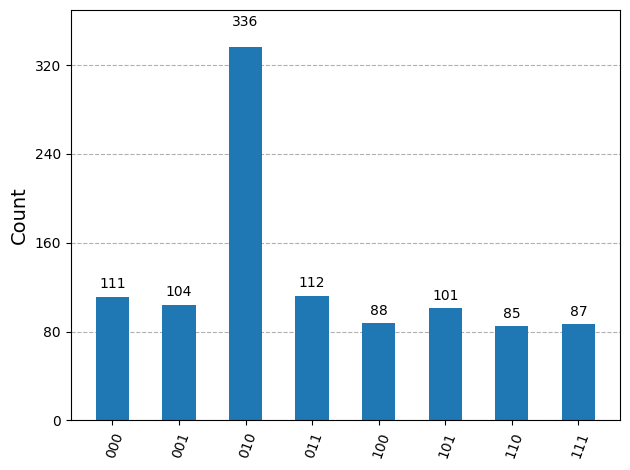

In [23]:
backend = AerSimulator()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

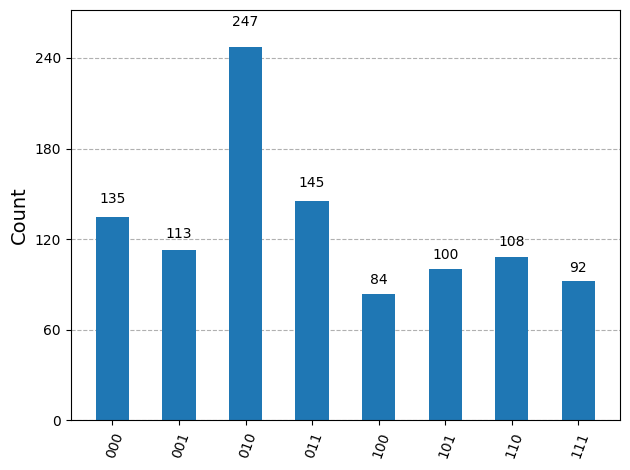

In [24]:
backend = FakeSherbrooke()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

##Amplitude Amplification General format



Let's construct the Amplitude Amplification for an arbitrary target state, and then turn that into a function we can use later.

In [25]:
def diffusion_operator(qc, num_main_qubits, ancilla_qubit):

    # Apply H + X to all main qubits
    for i in range(num_main_qubits):
        qc.h(i)
        qc.x(i)

    # Apply multi-controlled
    control_qubits = list(range(num_main_qubits))
    qc.compose(MCMTGate(XGate(), len(control_qubits), 1),
               control_qubits + [ancilla_qubit], inplace=True)

    # Apply X + H to all main qubits (uncompute)
    for i in range(num_main_qubits):
        qc.x(i)
        qc.h(i)

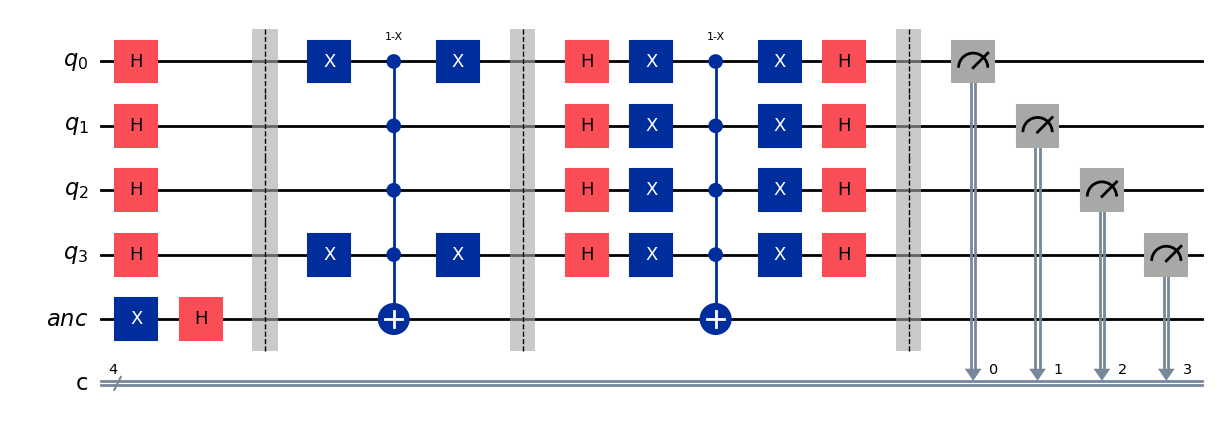

In [26]:
# Setup
target_state = '0110'
num_qubits = len(target_state)

# Create quantum circuit with main register + ancilla qubit
qr = QuantumRegister(num_qubits, 'q')
anc = QuantumRegister(1, 'anc')
cr = ClassicalRegister(num_qubits, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Initialize
for i in range(num_qubits):
    qc.h(qr[i])
qc.x(anc[0])
qc.h(anc[0])
qc.barrier()

# Oracle

mark_target_state(qc, target_state, anc[0])
qc.barrier()

# Diffusion operator using diffusion_operator function
diffusion_operator(qc, num_qubits, anc[0])
qc.barrier()

# Measure
qc.measure(qr, cr)

qc.draw(output='mpl')

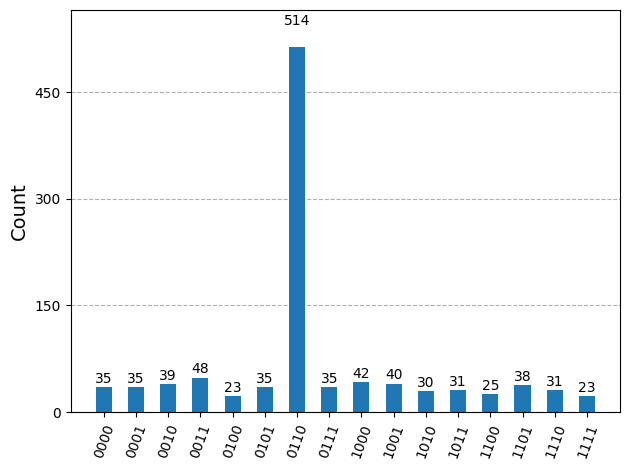

In [27]:
backend = AerSimulator()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

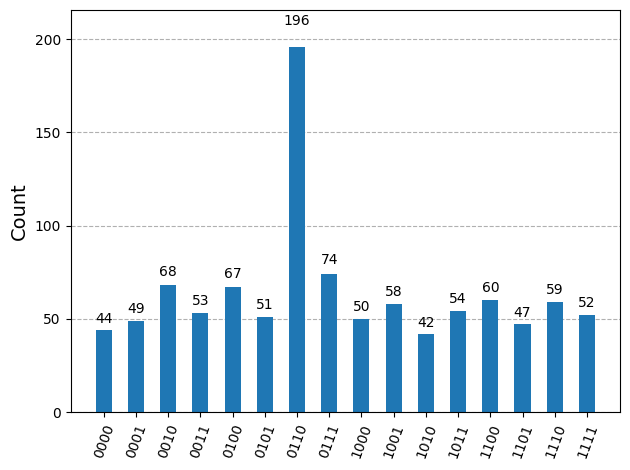

In [28]:
backend = FakeSherbrooke()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

Can you do the same task but with more target states?

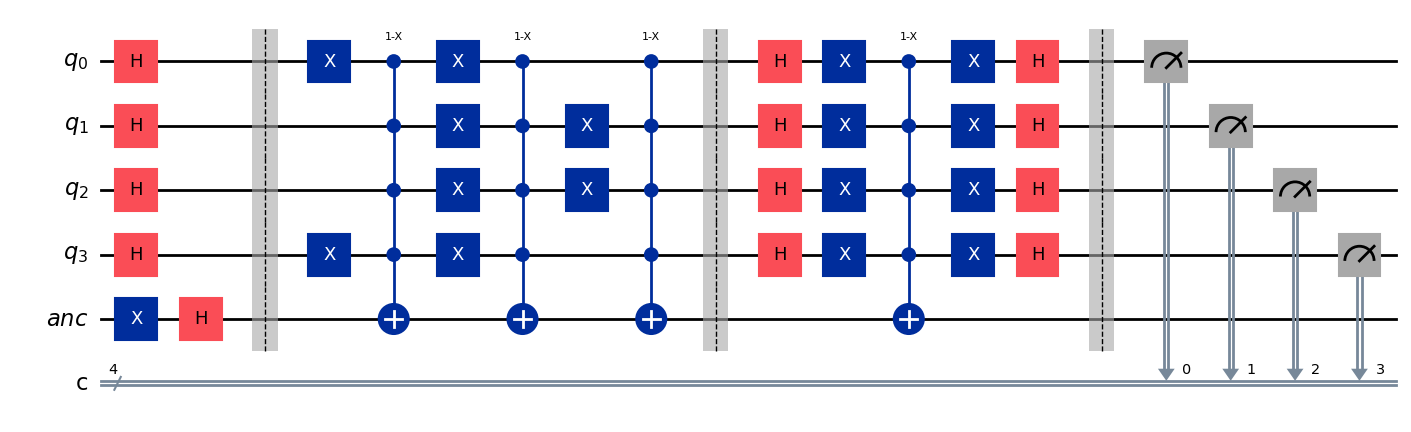

In [41]:
def diffusion_operator(qc, num_main_qubits, ancilla_qubit):
    # Apply H + X to all main qubits
    for i in range(num_main_qubits):
        qc.h(i)
        qc.x(i)

    # Apply multi-controlled Z (equivalent to MCT with ancilla in |-> state)
    # This flips the phase of the |00...0⟩ state
    control_qubits = list(range(num_main_qubits))
    qc.compose(MCMTGate(XGate(), len(control_qubits), 1),
               control_qubits + [ancilla_qubit], inplace=True)

    # Apply X + H to all main qubits (uncompute)
    for i in range(num_main_qubits):
        qc.x(i)
        qc.h(i)

# Setup for multiple target states
target_states = ['0110', '1001', '1111']
num_qubits = len(target_states[0])

# Create quantum circuit with main register + ancilla qubit
qr = QuantumRegister(num_qubits, 'q')
anc = QuantumRegister(1, 'anc')
cr = ClassicalRegister(num_qubits, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Initialize: Put main qubits in superposition and ancilla in |-> state
for i in range(num_qubits):
    qc.h(qr[i])
qc.x(anc[0])
qc.h(anc[0])
qc.barrier()

# Oracle for multiple target states
mark_target_states(qc, target_states, anc[0])
qc.barrier()

# Diffusion operator
diffusion_operator(qc, num_qubits, anc[0])
qc.barrier()

# Measure
qc.measure(qr, cr)

qc.draw(output='mpl', fold=-1)

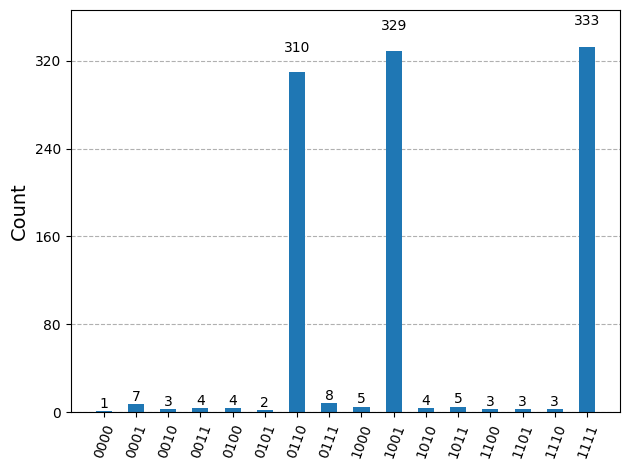

In [42]:
backend = AerSimulator()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

#4/ Grover's Algorithm

Number of qubits: 3
Search space size (N): 8
Number of solutions (M): 1
Optimal Grover iterations (R): 2
Applied Grover iteration 1/2
Applied Grover iteration 2/2

Circuit depth: 20
Total gates: 46


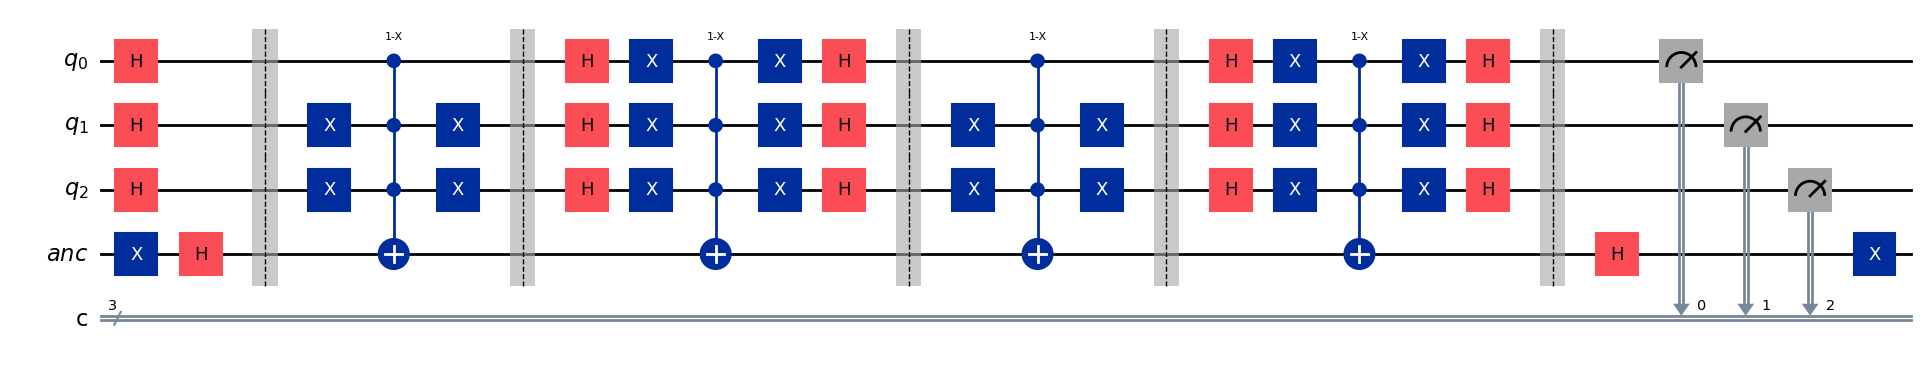

In [30]:
target_state = '001'
num_qubits = len(target_state)

# Calculate optimal number of Grover iterations
# For N items ≈ π/4 * sqrt(N)

N = 2**num_qubits  # 16 for 4 qubits
M = 1 # Number of solutions. Assuming one target state for now.
R = int(math.pi/4 * math.sqrt(N))  # Optimal number of iterations

print(f"Number of qubits: {num_qubits}")
print(f"Search space size (N): {N}")
print(f"Number of solutions (M): {M}")
print(f"Optimal Grover iterations (R): {R}")

# Create quantum circuit
qr = QuantumRegister(num_qubits, 'q')
anc = QuantumRegister(1, 'anc')
cr = ClassicalRegister(num_qubits, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Initialize: create equal superposition
for i in range(num_qubits):
    qc.h(qr[i])
qc.x(anc[0])
qc.h(anc[0])
qc.barrier()

# Apply Grover iterations (Oracle + Diffusion) R times
for iteration in range(R):
    # Oracle: mark the target state
    mark_target_state(qc, target_state, num_qubits)  # ancilla is at index num_qubits
    qc.barrier()

    # Diffusion: inversion about the mean
    diffusion_operator(qc, num_qubits, num_qubits)  # ancilla is at index num_qubits
    qc.barrier()

    print(f"Applied Grover iteration {iteration + 1}/{R}")

# Return ancilla to |-> basis (unprepare)
qc.h(anc[0])
qc.x(anc[0])

# Measure the main qubits
qc.measure(qr, cr)

print(f"\nCircuit depth: {qc.depth()}")
print(f"Total gates: {qc.size()}")
qc.draw(output='mpl', fold=-1)

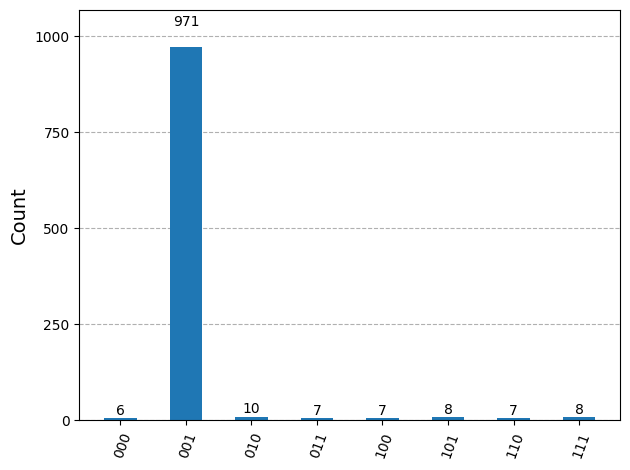

In [31]:
backend = AerSimulator()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

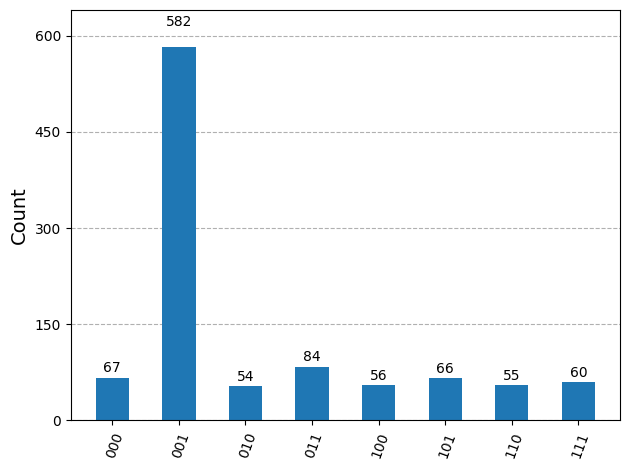

In [32]:
backend = FakeSherbrooke()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

### Exercice

Can you extend this to now perform Grover's search with two target strings? Once you've got that working, consider the following questions:

How many measurements (shots) would you need to perform to be convinced that you found the two target strings?
Does the optimal number of iterations change? If yes, then how so?

Number of qubits: 4
Search space size (N): 16
Number of solutions (M): 2
Optimal Grover iterations (R): 2
Applying Grover iteration 1/2
Applying Grover iteration 2/2

Circuit depth: 22
Total gates: 62
Target states to find: ['0010', '1111']


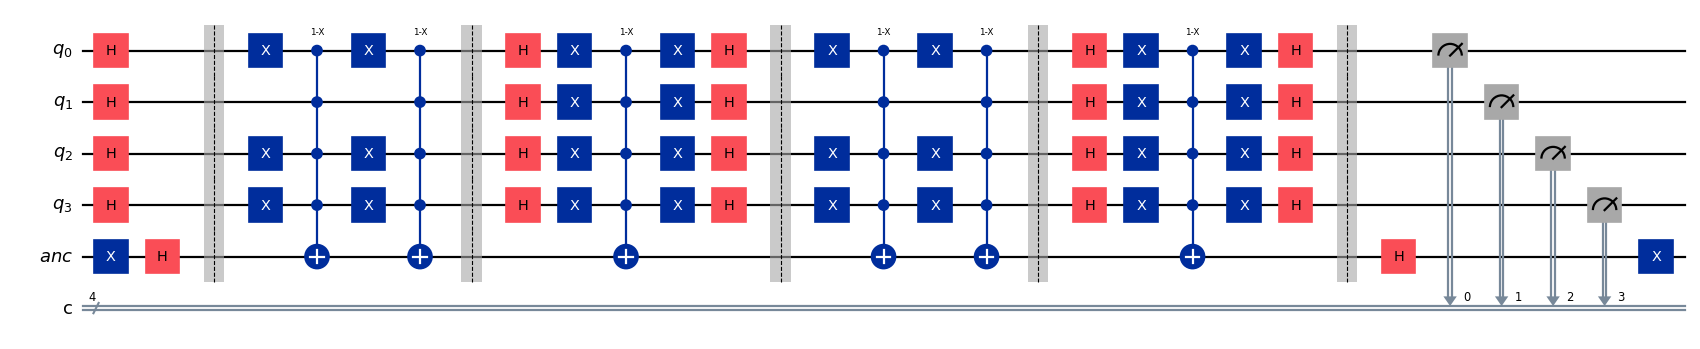

In [48]:
target_states = ['0010','1111']
num_qubits = len(target_states[0])
M = len(target_states)  # Number of solutions

# Calculate optimal number of Grover iterations
N = 2**num_qubits  # 8 for 3 qubits
R = int(math.pi/4 * math.sqrt(N/M))  # Optimal number of iterations

print(f"Number of qubits: {num_qubits}")
print(f"Search space size (N): {N}")
print(f"Number of solutions (M): {M}")
print(f"Optimal Grover iterations (R): {R}")

# Create quantum circuit
qr = QuantumRegister(num_qubits, 'q')
anc = QuantumRegister(1, 'anc')
cr = ClassicalRegister(num_qubits, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Initialize: create equal superposition
for i in range(num_qubits):
    qc.h(qr[i])
qc.x(anc[0])
qc.h(anc[0])
qc.barrier()

# Apply Grover iterations (Oracle + Diffusion) R times
for iteration in range(R):
    print(f"Applying Grover iteration {iteration + 1}/{R}")

    # Oracle: mark all target states
    mark_target_states(qc, target_states, anc[0])
    qc.barrier()

    # Diffusion: inversion about the mean
    diffusion_operator(qc, num_qubits, anc[0])
    qc.barrier()

# Return ancilla to |0⟩ state
qc.h(anc[0])
qc.x(anc[0])

# Measure the main qubits
qc.measure(qr, cr)

print(f"\nCircuit depth: {qc.depth()}")
print(f"Total gates: {qc.size()}")
print(f"Target states to find: {target_states}")
qc.draw(output='mpl', fold=-1, scale=0.8)

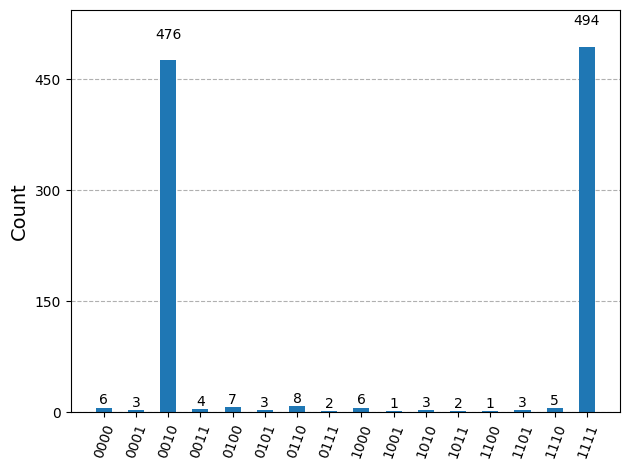

In [49]:
backend = AerSimulator()

# Transpile the circuit to the simulator's basis gates
transpiled_qc = transpile(qc, backend)

job = backend.run(transpiled_qc, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)